# Die Gamma-Funktion

## Fakultät

Die Fakultät wird berechnet als:

$5! = 5 \times 4 \times 3 \times 2 \times 1$ \
$4! = 4 \times 3 \times 2 \times 1$

Alternativ kann man $5!$ schreiben als:

$ 5! = 5 \times 4!$ \
$n! = n \times (n-1)! == (n-1) = n!/n$

Mit dieser Formel lässt sich elegant herleiten, dass $0! = 1$ sein muss.

$0! = 1!/1 = 1$

Setzen wir nun $-1$ ein:

$(-1)! = 0! / 0$

Müsste man durch $0$ dividieren, ergo ist die Fakultät für $-1$ nicht definiert.

## Eigenschaften der Fakultät

1. $ f(1) = 1 $

2. $ f(x+1) = x f(x) \quad x > 0 $

3. $f$ wächst schnell. 

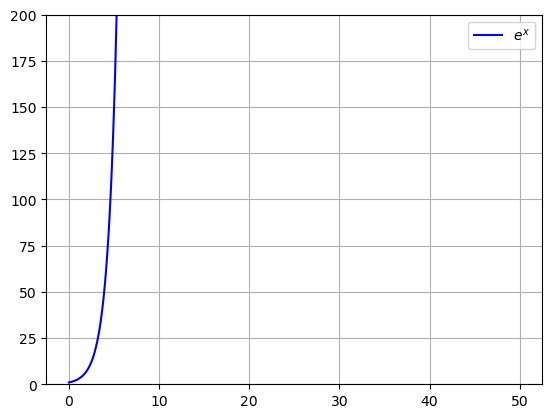

In [36]:
# plot e^x

import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 50, 400)
plt.ylim(0, 200)
plt.plot(x, np.exp(x), label='$e^x$', color='blue')
plt.legend()
plt.grid(True)
plt.savefig('imgs/exponential_plot.png')

## $f$ wächst schnell?

$ e^x $ wächst auch schnell:

<div><img src="imgs/exponential_plot.png" width="500"/></div>


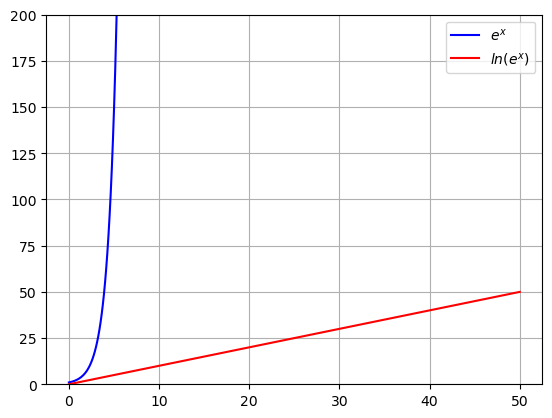

In [37]:
# plot ln(e^x)

import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 50, 400)
plt.ylim(0, 200)
plt.plot(x, np.exp(x), label='$e^x$', color='blue')
plt.plot(x, np.log(np.exp(x)), label='$ln(e^x)$', color='red')
plt.legend()
plt.grid(True)
plt.savefig('imgs/exponential_log_plot.png')

## $f$ wächst schnell?

Aber $ln(e^x)$ ist linear:

<div><img src="imgs/exponential_log_plot.png" width="500"/></div>

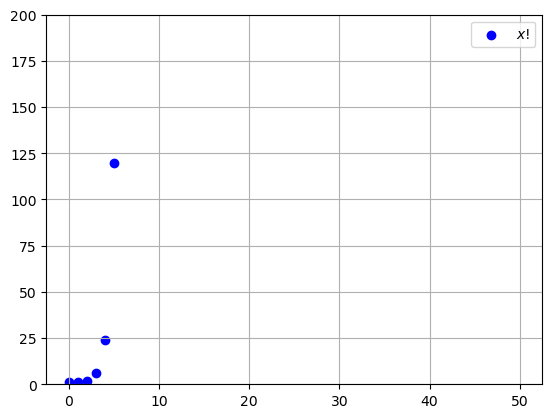

In [33]:
# plot x!

import matplotlib.pyplot as plt
import numpy as np
import math

x = list(range(51))
y = [math.factorial(i) for i in x]
plt.ylim(0, 200)
plt.scatter(x, y, label='$x!$', color='blue')
plt.legend()
plt.grid(True)
plt.savefig('imgs/factorial_plot.png')

## $f$ wächst schnell?

$x!$ wächst auch schnell:

<div><img src="imgs/factorial_plot.png" width="500"/></div>

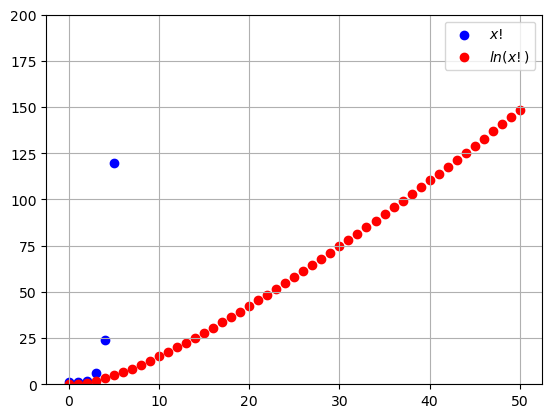

In [34]:
# plot ln(x!)

import matplotlib.pyplot as plt
import numpy as np
import math

x = list(range(51))
y = [math.factorial(i) for i in x]
y1 = [math.log(math.factorial(i)) for i in x]
plt.ylim(0, 200)
plt.scatter(x, y, label='$x!$', color='blue')
plt.scatter(x, y1, label='$ln(x!)$', color='red')
plt.legend()
plt.grid(True)
plt.savefig('imgs/factorial_log_plot.png')

## $f$ wächst schnell?

Aber sogar $ln(x!)$ hat eine kleine Kurve:

<div><img src="imgs/factorial_log_plot.png" width="500"/></div>

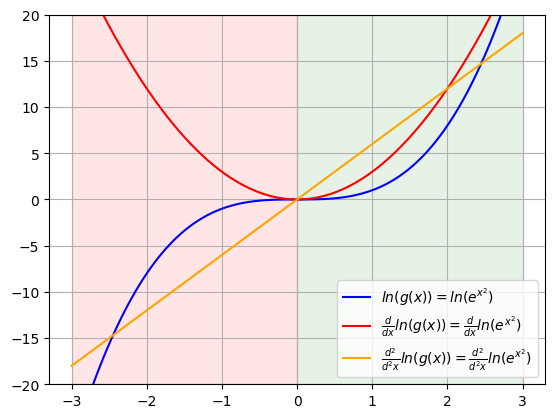

In [64]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3, 3, 400)
plt.ylim(-20, 20)
plt.plot(x, x**3, label='$ln(g(x)) = ln(e^{x^2})$', color='blue')
plt.plot(x, 3*x**2, label='$\\frac{d}{d x} ln(g(x)) = \\frac{d}{d x} ln(e^{x^2})$', color='red')
plt.plot(x, 6*x, label='$\\frac{d^2}{d^2 x} ln(g(x)) = \\frac{d^2}{d^2 x} ln(e^{x^2})$', color='orange')
plt.legend()
plt.axvspan(0, 3, color='green', alpha=0.1)
plt.axvspan(-3, 0, color='red', alpha=0.1)
plt.grid(True)
plt.savefig('imgs/log_convex.png')

## $f$ wächst schnell?

Für eine zweifach ableitbare Funktion $g : \mathbb{R} \rightarrow \mathbb{R} $, e.g. 
    
$ g(x) = e^{x^2} $

können wir das etwas rigoroser ausdrücken:

<div><img src="imgs/log_convex.png" width="500"/></div>

$\rightarrow$ wir nennen das: "Logarithmisch Konvex"


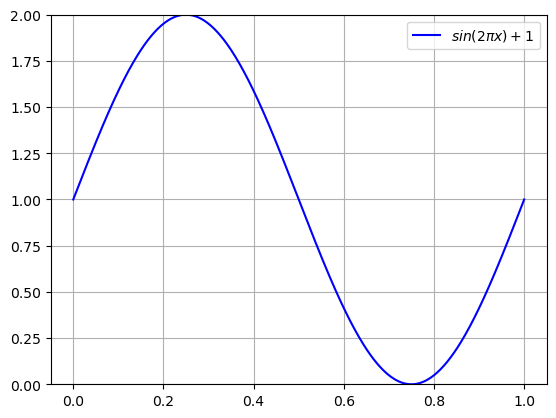

In [85]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1, 400)
plt.ylim(0,2)
plt.plot(x, np.sin(2*np.pi*x)+1, label='$sin(2 \\pi x) + 1$', color='blue')
plt.legend()
plt.grid(True)
plt.savefig('imgs/sin_1.png')

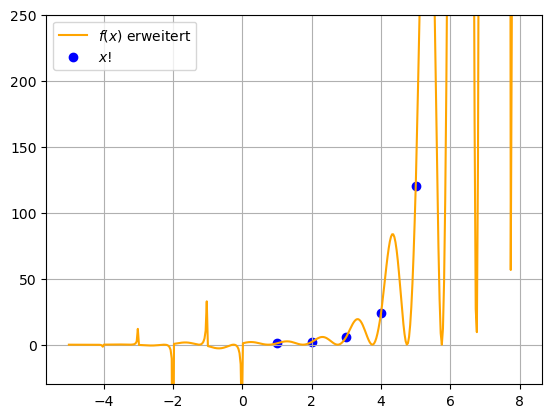

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from lazy import lazy

def f(x):
    res = np.zeros_like(x)
    
    # 1. Base Case: 0 <= x < 1
    mask_base = (x >= 0) & (x < 1)
    if np.any(mask_base):
        res[mask_base] = np.sin(2 * np.pi * x[mask_base])+1
        
    # 2. Step Down: f(x) = x * f(x-1) for x >= 1
    mask_high = (x >= 1)
    if np.any(mask_high):
        res[mask_high] = x[mask_high] * f(x[mask_high] - 1)
        
    # 3. Step Up: f(x) = f(x+1) / x for x < 0
    mask_low = (x < 0)
    if np.any(mask_low):
        res[mask_low] = f(x[mask_low] + 1) / x[mask_low]

    return res

x = np.linspace(-5, 8, 400)
plt.ylim(-30, 250)
plt.plot(x, f(x), label='$f(x) \\text{ erweitert}$', color='orange')
plt.scatter(range(1, 9), [math.factorial(i) for i in range(1, 9)], label='$x!$', color='blue')
plt.legend()
plt.grid(True)
plt.savefig('imgs/sin_extended.png')

## Welche Funktion erfüllt diese Kriterien für $\mathbb{R}$?

Eine beliebige Funktion $  f : [0, 1) \rightarrow \mathbb{R} $ kann durch die rekursive Eigenschaft $ f(x+1) = x f(x) $ auf ganz $\mathbb{R}$ erweitert werden. Wenn wir zusätzlich $ f(1) = 1 $ definieren, schneidet die resultierende Funktion die Fakultät, e.g.

$ f(x) : \begin{cases} 
[0, 1) \rightarrow \mathbb{R} \\
x \mapsto sin(2 \pi x) + 1
\end{cases}
$


<p>
    <img src="imgs/sin_1.png" class="fragment" width="250"/>
    <img src="imgs/sin_extended.png" class="fragment" width="250"/>
</p>

$\rightarrow$ Wir haben schon 2 von 3 Kriterien erfüllt!

## 3. Schritt

Gamma ist die einzige Funktion, die constraints erfüllt (ohne Beweis)

## x. Schritt

Gamma-Funktion von -0.5 

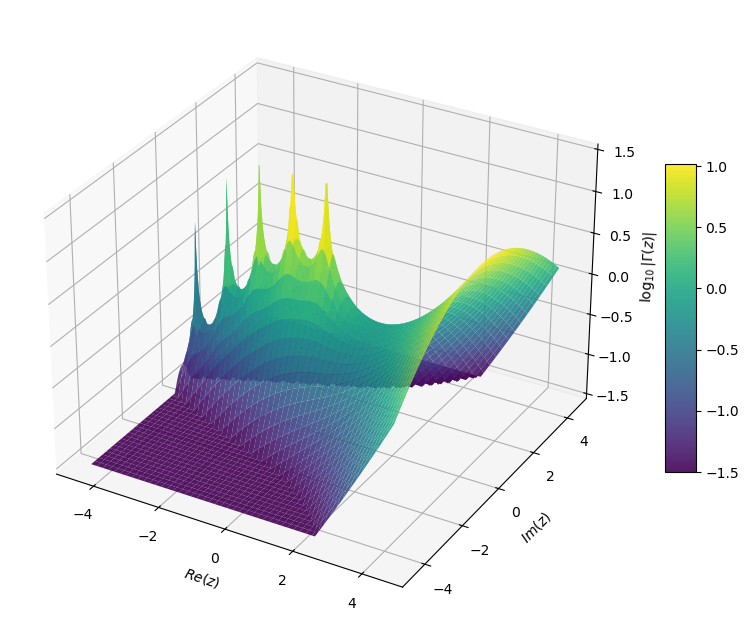

In [ ]:
# es grosses merci an gemini

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from matplotlib import cm

# Define the grid
x = np.linspace(-4.5, 4.5, 500)
y = np.linspace(-4.5, 4.5, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Calculate the Gamma function and its magnitude
Gamma_Z = gamma(Z)
magnitude = np.abs(Gamma_Z)
log_magnitude = np.log10(magnitude)

# Clip for better visual range
# Magnitude varies greatly near poles (0, -1, -2, -3, -4)
# and for large positive Re(z).
Z_plot = np.clip(log_magnitude, -1.5, 1.5)

# Plot 1: 3D Surface Plot
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')
surf = ax1.plot_surface(X, Y, Z_plot, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel(r'$Re(z)$')
ax1.set_ylabel(r'$Im(z)$')
ax1.set_zlabel(r'$\log_{10}|\Gamma(z)|$')
fig1.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
plt.savefig('imgs/gamma_3d_surface.png')

<div>
<img src="imgs/gamma_3d_surface.png" width="500"/>
</div>
